In [ ]:
import sys
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print(sys.version)

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

print("Libraries loaded successfully")
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded")

c:\Users\jassk\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]
Libraries loaded successfully


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1031.13it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded


In [ ]:
# =========================================
# 1. LOAD AND FILTER DATASET
# =========================================

# Validate dataset exists
dataset_path = "News_Category_Dataset_v3.json"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"Dataset '{dataset_path}' not found.\n"
        "Download from: https://www.kaggle.com/datasets/rmisra/news-category-dataset\n"
        "Place in current working directory."
    )

# Load dataset
df = pd.read_json(dataset_path, lines=True)
print(f"✓ Loaded {len(df)} documents")

# ⭐ ADD THIS (Create 'text' column):
df["text"] = (
    df["headline"].fillna("") + " " +
    df["short_description"].fillna("")
).str.strip()

# ⭐ ADD THIS (Remove empty rows):
df = df[df["text"].str.len() > 0]
print(f"Documents with text: {len(df)}")

# Define clean_text function
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

print("✓ Text column created successfully")

✓ Loaded 209527 documents
Documents with text: 209522
✓ Text column created successfully


In [ ]:
# =========================================
# 2. FAST SEMANTIC FILTERING
#    (KEYWORD PREFILTER -> SEMANTIC FILTER -> SAMPLE)
# =========================================

# Step 1: broad keyword prefilter
candidate_df = df[df["text"].str.contains(
    r"\b(ai|artificial intelligence|machine learning|data science|deep learning|neural network|algorithm|nlp|robotics|automation|computer vision|language model)\b",
    case=False,
    na=False,
    regex=True
)].copy()

print("Candidate docs after keyword prefilter:", len(candidate_df))

# Step 2: semantic topic descriptions
topic_descriptions = [
    "articles about artificial intelligence machine learning deep learning neural networks data science intelligent systems and automation",
    "news about AI research machine learning applications natural language processing computer vision robotics and predictive models",
    "content focused on artificial intelligence technology machine learning methods AI software data science innovation and algorithms"
]

candidate_texts = candidate_df["text"].tolist()

candidate_embeddings = model.encode(
    candidate_texts,
    normalize_embeddings=True,
    show_progress_bar=True,
    batch_size=64
)

topic_embeddings = model.encode(
    topic_descriptions,
    normalize_embeddings=True,
    show_progress_bar=False
)

topic_vector = np.mean(topic_embeddings, axis=0)
topic_vector = topic_vector / np.linalg.norm(topic_vector)

semantic_scores = candidate_embeddings @ topic_vector
candidate_df["semantic_ai_score"] = semantic_scores

# Step 3: Cap for speed (AFTER semantic scores computed)
MAX_CANDIDATES = 5000
if len(candidate_df) > MAX_CANDIDATES:
    candidate_df = candidate_df.nlargest(MAX_CANDIDATES, "semantic_ai_score").copy()

print("Candidate docs used for semantic filtering:", len(candidate_df))

# Step 4: Analyze threshold sensitivity
print("\nThreshold sensitivity analysis:")
for threshold in [0.25, 0.30, 0.35, 0.40, 0.45]:
    n = len(candidate_df[candidate_df["semantic_ai_score"] >= threshold])
    print(f"  Threshold {threshold}: {n:5d} documents")

# Step 5: Apply threshold
SIM_THRESHOLD = 0.35
ai_df = candidate_df[candidate_df["semantic_ai_score"] >= SIM_THRESHOLD].copy()
if len(ai_df) == 0:
    raise ValueError("No documents found after semantic filtering. Try lowering SIM_THRESHOLD.")

print("Semantically filtered AI docs:", len(ai_df))

print("\nTop semantic matches:")
for _, row in ai_df.nlargest(10, "semantic_ai_score")[["text", "semantic_ai_score"]].iterrows():
    print(f"{row['semantic_ai_score']:.4f} | {row['text'][:180]}")

N_DOCS = min(1000, len(ai_df))
docs_clean_raw = ai_df["text"].sample(n=N_DOCS, random_state=42).tolist()

print(f"\nFinal selected docs: {len(docs_clean_raw)}")

C:\Users\jassk\AppData\Local\Temp\ipykernel_21992\801191566.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  candidate_df = df[df["text"].str.contains(


Candidate docs after keyword prefilter: 89


Batches: 100%|██████████| 2/2 [00:01<00:00,  1.60it/s]

Candidate docs used for semantic filtering: 89

Threshold sensitivity analysis:
  Threshold 0.25:    54 documents
  Threshold 0.3:    42 documents
  Threshold 0.35:    37 documents
  Threshold 0.4:    20 documents
  Threshold 0.45:    14 documents
Semantically filtered AI docs: 37

Top semantic matches:
0.5768 | Artificial Intelligence Is Here To Help Us, Microsoft Boss Jean-Philippe Courtois Says "We can augment human capabilities and impact."
0.5610 | How To Stop Worrying And Love Artificial Intelligence A new book finds the heart in our cold, robotic future.
0.5396 | Artificial Intelligence Is Here To Change Your Life The revolution began before you even realized it.
0.5178 | Artificial Intelligence Technology Is 'Breaking Out of the Box' "The exponential improvement in the elements of computing is not about to run out of gas. We've got generations more
0.5114 | In a Huge Breakthrough, Google’s AI Beats a Top Player at the Game of Go IN A MAJOR breakthrough for artificial intelligen

In [4]:
# =========================================
# 3. BLOCKERS
# =========================================

blockers_raw = [
    "This document discusses important concepts in systems, models, data, learning, evaluation, performance, optimization and methods across many domains.",
    "A broad overview of AI, machine learning, data science, systems, development and evaluation with general principles and widely applicable concepts.",
    "General discussion of technology, research, science, modeling, metrics, methods and performance in modern computing and analytics.",
    "Artificial intelligence and machine learning involve models, training, evaluation, optimization, data pipelines, performance metrics and research methods used across applications.",
    "Data science includes modeling, analytics, machine learning, evaluation, experimentation, performance measurement and optimization in modern intelligent systems.",
    "Modern AI systems rely on data, algorithms, model training, evaluation, benchmarking, optimization and deployment in practical computing environments.",
    "Machine learning and artificial intelligence are widely used in data analysis, research, prediction, classification, optimization and decision support systems.",
    "Evaluation methods in AI and machine learning often involve metrics, models, datasets, experiments, performance analysis and optimization techniques.",
    "Research in artificial intelligence covers machine learning, data science, modeling, system performance, analytics, optimization and evaluation strategies.",
    "AI, data science and machine learning share concepts such as data processing, model development, experimentation, evaluation and performance improvement."
]

docs_clean = [clean_text(d) for d in docs_clean_raw]
blockers = [clean_text(b) for b in blockers_raw]

print("Clean docs:", len(docs_clean))
print("Blockers:", len(blockers))

Clean docs: 37
Blockers: 10


In [5]:
# =========================================
# 4. QUERY-GOLD PAIRS
# =========================================

def get_gold_indices(n_docs, n_splits=4):
    """Generate evenly-spaced gold indices."""
    return [int(n_docs * (i+1)/(n_splits+1)) for i in range(n_splits)]

gold_indices = get_gold_indices(N_DOCS, n_splits=4)

query_gold_pairs = []
for idx in gold_indices:
    if idx < len(docs_clean):
        doc_text = docs_clean[idx]
        short_query = " ".join(doc_text.split()[:8])
        query_gold_pairs.append((short_query, idx))

print("Query-gold pairs:")
for q, idx in query_gold_pairs:
    print(f"Query: {q}... -> Gold doc index: {idx}")
print(f"Total query-gold pairs: {len(query_gold_pairs)}")

Query-gold pairs:
Query: world s business elite are stressed about our... -> Gold doc index: 7
Query: ai predicts autism based on infant brain scans... -> Gold doc index: 14
Query: why are digital assistants like siri given female... -> Gold doc index: 22
Query: inside facebook s plan to build an artificial... -> Gold doc index: 29
Total query-gold pairs: 4


In [6]:
# =========================================
# 5. BUILD CORPORA AND EMBEDDINGS
# =========================================

docs_attacked = docs_clean + blockers
print(f"Blockers as % of attacked corpus: {len(blockers) / len(docs_attacked) * 100:.1f}%")
blocker_start_idx = len(docs_clean)

doc_emb_clean = model.encode(docs_clean, normalize_embeddings=True)
doc_emb_attacked = model.encode(docs_attacked, normalize_embeddings=True)

print("Clean embeddings shape:", doc_emb_clean.shape)
print("Attacked embeddings shape:", doc_emb_attacked.shape)
print("Blockers start index:", blocker_start_idx)

Blockers as % of attacked corpus: 21.3%
Clean embeddings shape: (37, 384)
Attacked embeddings shape: (47, 384)
Blockers start index: 37


In [7]:
# =========================================
# 6. SPARSE INDEXES
# =========================================

tokenized_clean = [doc.split() for doc in docs_clean]
tokenized_attacked = [doc.split() for doc in docs_attacked]

bm25_clean = BM25Okapi(tokenized_clean)
bm25_attacked = BM25Okapi(tokenized_attacked)

tfidf_clean = TfidfVectorizer(stop_words="english")
tfidf_attacked = TfidfVectorizer(stop_words="english")

tfidf_matrix_clean = tfidf_clean.fit_transform(docs_clean)
tfidf_matrix_attacked = tfidf_attacked.fit_transform(docs_attacked)

print("BM25 ready")
print("TF-IDF ready")

BM25 ready
TF-IDF ready


In [8]:
# =========================================
# 7. RETRIEVAL FUNCTIONS
# =========================================

def retrieve_topk_precomputed(query, docs, doc_emb, k=5):
    k = min(k, len(docs))  # ADD THIS LINE - Cap k to corpus size
    q = clean_text(query)
    q_emb = model.encode([q], normalize_embeddings=True)[0]
    scores = doc_emb @ q_emb
    top_idx = np.argsort(-scores)[:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

def retrieve_bm25(query, docs, bm25, k=5):
    k = min(k, len(docs))  # ADD THIS LINE
    tokenized_query = clean_text(query).split()
    scores = bm25.get_scores(tokenized_query)
    top_idx = np.argsort(scores)[::-1][:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

def retrieve_tfidf(query, docs, tfidf_matrix, vectorizer, k=5):
    k = min(k, len(docs))
    q_vec = vectorizer.transform([clean_text(query)])
    scores = cosine_similarity(q_vec, tfidf_matrix)[0]
    top_idx = scores.argsort()[::-1][:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

def retrieve_hybrid(query, docs, doc_emb, bm25, k=5, alpha=0.5):
    k = min(k, len(docs))
    q_emb = model.encode([clean_text(query)], normalize_embeddings=True)[0]
    dense_scores = doc_emb @ q_emb
    tokenized_query = clean_text(query).split()
    bm25_scores = bm25.get_scores(tokenized_query)

    dense_scores = np.array(dense_scores)
    bm25_scores = np.array(bm25_scores)

    dense_norm = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-8)
    bm25_norm = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min() + 1e-8)

    hybrid_scores = alpha * dense_norm + (1 - alpha) * bm25_norm

    top_idx = np.argsort(hybrid_scores)[::-1][:k]
    return [(int(i), docs[int(i)], float(hybrid_scores[int(i)])) for i in top_idx]

In [9]:
# =========================================
# 8. HELPER FUNCTIONS FOR RANKING AND METRICS
# =========================================

def get_rank_of_doc(results, target_idx):
    for rank, (idx, _, _) in enumerate(results, start=1):
        if idx == target_idx:
            return rank
    return None

def hit_at_k(rank, k):
    return 1 if rank is not None and rank <= k else 0

def reciprocal_rank(rank):
    return 1.0 / rank if rank is not None else 0.0

def evaluate_method(query_gold_pairs, retrieve_fn_clean, retrieve_fn_attacked, k=10):
    clean_hits = []
    attacked_hits = []
    clean_rrs = []
    attacked_rrs = []

    for query, gold_idx in query_gold_pairs:
        clean_results = retrieve_fn_clean(query)
        attacked_results = retrieve_fn_attacked(query)

        clean_rank = get_rank_of_doc(clean_results, gold_idx)
        attacked_rank = get_rank_of_doc(attacked_results, gold_idx)

        clean_hits.append(hit_at_k(clean_rank, k))
        attacked_hits.append(hit_at_k(attacked_rank, k))

        clean_rrs.append(reciprocal_rank(clean_rank))
        attacked_rrs.append(reciprocal_rank(attacked_rank))

    return {
        "Hit@10 Clean": np.mean(clean_hits),
        "Hit@10 Attacked": np.mean(attacked_hits),
        "MRR@10 Clean": np.mean(clean_rrs),
        "MRR@10 Attacked": np.mean(attacked_rrs),
    }

In [10]:
# =========================================
# 9. BASIC DENSE BEFORE VS AFTER EXAMPLE
# =========================================

K_BLOCKER_ANALYSIS = 5      # For blocker dominance visualization
K_EVALUATION = 10         # For retrieval metrics (Hit@10, MRR@10)

query = "What is artificial intelligence and machine learning?"
k = K_BLOCKER_ANALYSIS  # Use the constant

print("===== DENSE BEFORE (clean corpus) =====")
before = retrieve_topk_precomputed(query, docs_clean, doc_emb_clean, k)
for idx, text, score in before:
    print(f"[{idx}] score={score:.4f} | {text[:120]}...")

print("\n===== DENSE AFTER (clean + blockers) =====")
after = retrieve_topk_precomputed(query, docs_attacked, doc_emb_attacked, k)

blocker_hits = 0
for idx, text, score in after:
    is_blocker = idx >= blocker_start_idx
    blocker_hits += int(is_blocker)
    tag = "🚨BLOCKER" if is_blocker else "clean"
    print(f"[{idx}] {tag} score={score:.4f} | {text[:120]}...")

print(f"\nBlockers in top-{k}: {blocker_hits}/{k}")

===== DENSE BEFORE (clean corpus) =====
[15] score=0.5318 | artificial intelligence is here to change your life the revolution began before you even realized it...
[5] score=0.5080 | artificial intelligence is here to help us microsoft boss jean philippe courtois says we can augment human capabilities ...
[30] score=0.5034 | amazon is making it easier for companies to track you by adrienne lafrance like big data and social media before it the ...
[17] score=0.4739 | artificial intelligence technology is breaking out of the box the exponential improvement in the elements of computing i...
[9] score=0.4659 | how ai will redefine love artificial intelligence is beginning to disrupt entire industries from finance to medicine yet...

===== DENSE AFTER (clean + blockers) =====
[43] 🚨BLOCKER score=0.6790 | machine learning and artificial intelligence are widely used in data analysis research prediction classification optimiz...
[45] 🚨BLOCKER score=0.6753 | research in artificial intelligence 

In [11]:
# =========================================
# 10. TEST QUERIES
# =========================================

queries = [
    "What is data science?",
    "How does evaluation work in machine learning?",
    "How are models optimized in artificial intelligence?",
    "What are machine learning systems used for?"
]

k = 5
print("Queries loaded:", len(queries))

Queries loaded: 4


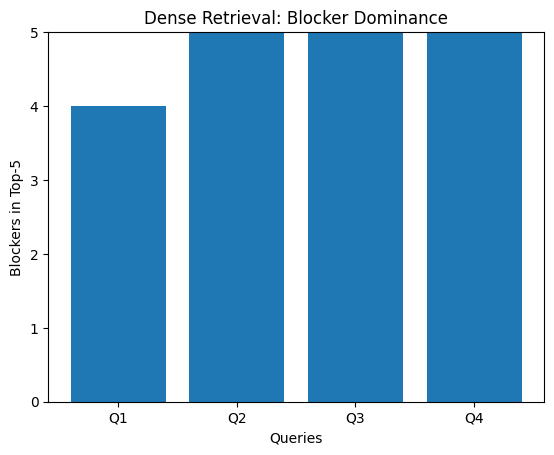

In [12]:
# =========================================
# 11. DENSE BLOCKER DOMINANCE
# =========================================
blocker_counts = []
for q in queries:
    after = retrieve_topk_precomputed(q, docs_attacked, doc_emb_attacked, K_BLOCKER_ANALYSIS)
    hits = sum(1 for idx, _, _ in after if idx >= blocker_start_idx)
    blocker_counts.append(hits)

plt.figure()
plt.bar(range(len(queries)), blocker_counts)
plt.xticks(range(len(queries)), [f"Q{i+1}" for i in range(len(queries))])
plt.ylim(0, K_BLOCKER_ANALYSIS)
plt.xlabel("Queries")
plt.ylabel(f"Blockers in Top-{K_BLOCKER_ANALYSIS}")
plt.title("Dense Retrieval: Blocker Dominance")
plt.show()

In [13]:
# =========================================
# 12. BM25 BEFORE VS AFTER
# =========================================

print("===== BM25 RESULTS (before vs after) =====")

for q in queries:
    print("\nQuery:", q)

    print("BEFORE (clean corpus)")
    before_results = retrieve_bm25(q, docs_clean, bm25_clean, k)
    for idx, text, score in before_results:
        print(f"  - [{idx}] clean score={score:.4f} | {text[:90]}...")

    print("AFTER (attacked corpus)")
    after_results = retrieve_bm25(q, docs_attacked, bm25_attacked, k)
    blocker_hits = sum(1 for idx, _, _ in after_results if idx >= blocker_start_idx)
    print(f"  Blockers in top-{k}: {blocker_hits}/{k}")

    for idx, text, score in after_results:
        tag = "🚨BLOCKER" if idx >= blocker_start_idx else "clean"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

===== BM25 RESULTS (before vs after) =====

Query: What is data science?
BEFORE (clean corpus)
  - [10] clean score=7.2162 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [24] clean score=2.8234 | alan turing s brother he should be alive today june 23rd is the centenary of the birth of ...
  - [19] clean score=2.8234 | is an ai arms race inevitable unlike nuclear weapons this new class can potentially target...
  - [25] clean score=2.8143 | big data and deep learning big deals or big delusions getting the most out deep learning w...
  - [30] clean score=2.3225 | amazon is making it easier for companies to track you by adrienne lafrance like big data a...
AFTER (attacked corpus)
  Blockers in top-5: 3/5
  - [10] clean score=5.2161 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [19] clean score=3.2884 | is an ai arms race inevitable unlike nuclear weapons this new class can potentiall

In [14]:
# =========================================
# 13. TF-IDF BEFORE VS AFTER
# =========================================

print("===== TF-IDF RESULTS (before vs after) =====")

for q in queries:
    print("\nQuery:", q)

    print("BEFORE (clean corpus)")
    before_results = retrieve_tfidf(q, docs_clean, tfidf_matrix_clean, tfidf_clean, k)
    for idx, text, score in before_results:
        print(f"  - [{idx}] clean score={score:.4f} | {text[:90]}...")

    print("AFTER (attacked corpus)")
    after_results = retrieve_tfidf(q, docs_attacked, tfidf_matrix_attacked, tfidf_attacked, k)
    blocker_hits = sum(1 for idx, _, _ in after_results if idx >= blocker_start_idx)
    print(f"  Blockers in top-{k}: {blocker_hits}/{k}")

    for idx, text, score in after_results:
        tag = "🚨BLOCKER" if idx >= blocker_start_idx else "clean"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

===== TF-IDF RESULTS (before vs after) =====

Query: What is data science?
BEFORE (clean corpus)
  - [10] clean score=0.5133 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [24] clean score=0.1421 | alan turing s brother he should be alive today june 23rd is the centenary of the birth of ...
  - [30] clean score=0.1343 | amazon is making it easier for companies to track you by adrienne lafrance like big data a...
  - [17] clean score=0.1090 | artificial intelligence technology is breaking out of the box the exponential improvement ...
  - [27] clean score=0.1051 | ai day will replace christmas as the most important holiday in less than 25 years some rel...
AFTER (attacked corpus)
  Blockers in top-5: 4/5
  - [10] clean score=0.4129 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [46] 🚨BLOCKER score=0.3856 | ai data science and machine learning share concepts such as data processing m

In [15]:
# =========================================
# 14. HYBRID BEFORE VS AFTER
# =========================================

print("===== HYBRID RESULTS (before vs after) =====")

for q in queries:
    print("\nQuery:", q)

    print("BEFORE (clean corpus)")
    before_results = retrieve_hybrid(q, docs_clean, doc_emb_clean, bm25_clean, k, alpha=0.5)
    for idx, text, score in before_results:
        print(f"  - [{idx}] clean score={score:.4f} | {text[:90]}...")

    print("AFTER (attacked corpus)")
    after_results = retrieve_hybrid(q, docs_attacked, doc_emb_attacked, bm25_attacked, k, alpha=0.5)
    blocker_hits = sum(1 for idx, _, _ in after_results if idx >= blocker_start_idx)
    print(f"  Blockers in top-{k}: {blocker_hits}/{k}")

    for idx, text, score in after_results:
        tag = "🚨BLOCKER" if idx >= blocker_start_idx else "clean"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

===== HYBRID RESULTS (before vs after) =====

Query: What is data science?
BEFORE (clean corpus)
  - [10] clean score=1.0000 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [30] clean score=0.3927 | amazon is making it easier for companies to track you by adrienne lafrance like big data a...
  - [17] clean score=0.3734 | artificial intelligence technology is breaking out of the box the exponential improvement ...
  - [25] clean score=0.3290 | big data and deep learning big deals or big delusions getting the most out deep learning w...
  - [19] clean score=0.3016 | is an ai arms race inevitable unlike nuclear weapons this new class can potentially target...
AFTER (attacked corpus)
  Blockers in top-5: 4/5
  - [10] clean score=1.0000 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [41] 🚨BLOCKER score=0.7267 | data science includes modeling analytics machine learning evaluation experime

In [16]:
# =========================================
# 15. GOLD DOCUMENT RANK TESTS
# =========================================

print("\n===== GOLD DOCUMENT RANK TEST: DENSE =====")
for query, gold_idx in query_gold_pairs:
    before_results = retrieve_topk_precomputed(query, docs_clean, doc_emb_clean, k=10)
    after_results = retrieve_topk_precomputed(query, docs_attacked, doc_emb_attacked, k=10)

    rank_before = get_rank_of_doc(before_results, gold_idx)
    rank_after = get_rank_of_doc(after_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank BEFORE attack:", rank_before)
    print("Rank AFTER attack:", rank_after)

print("\n===== GOLD DOCUMENT RANK TEST: BM25 =====")
for query, gold_idx in query_gold_pairs:
    before_results = retrieve_bm25(query, docs_clean, bm25_clean, k=10)
    after_results = retrieve_bm25(query, docs_attacked, bm25_attacked, k=10)

    rank_before = get_rank_of_doc(before_results, gold_idx)
    rank_after = get_rank_of_doc(after_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank BEFORE attack:", rank_before)
    print("Rank AFTER attack:", rank_after)

print("\n===== GOLD DOCUMENT RANK TEST: TF-IDF =====")
for query, gold_idx in query_gold_pairs:
    before_results = retrieve_tfidf(query, docs_clean, tfidf_matrix_clean, tfidf_clean, k=10)
    after_results = retrieve_tfidf(query, docs_attacked, tfidf_matrix_attacked, tfidf_attacked, k=10)

    rank_before = get_rank_of_doc(before_results, gold_idx)
    rank_after = get_rank_of_doc(after_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank BEFORE attack:", rank_before)
    print("Rank AFTER attack:", rank_after)

print("\n===== GOLD DOCUMENT RANK TEST: HYBRID =====")
for query, gold_idx in query_gold_pairs:
    before_results = retrieve_hybrid(query, docs_clean, doc_emb_clean, bm25_clean, k=10, alpha=0.5)
    after_results = retrieve_hybrid(query, docs_attacked, doc_emb_attacked, bm25_attacked, k=10, alpha=0.5)

    rank_before = get_rank_of_doc(before_results, gold_idx)
    rank_after = get_rank_of_doc(after_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank BEFORE attack:", rank_before)
    print("Rank AFTER attack:", rank_after)


===== GOLD DOCUMENT RANK TEST: DENSE =====

Query: world s business elite are stressed about our
Gold document index: 7
Rank BEFORE attack: 1
Rank AFTER attack: 1

Query: ai predicts autism based on infant brain scans
Gold document index: 14
Rank BEFORE attack: 1
Rank AFTER attack: 1

Query: why are digital assistants like siri given female
Gold document index: 22
Rank BEFORE attack: 1
Rank AFTER attack: 1

Query: inside facebook s plan to build an artificial
Gold document index: 29
Rank BEFORE attack: 1
Rank AFTER attack: 1

===== GOLD DOCUMENT RANK TEST: BM25 =====

Query: world s business elite are stressed about our
Gold document index: 7
Rank BEFORE attack: 1
Rank AFTER attack: 1

Query: ai predicts autism based on infant brain scans
Gold document index: 14
Rank BEFORE attack: 1
Rank AFTER attack: 1

Query: why are digital assistants like siri given female
Gold document index: 22
Rank BEFORE attack: 1
Rank AFTER attack: 1

Query: inside facebook s plan to build an artificial
Gold

In [17]:
# =========================================
# 16. RETRIEVAL METRICS: HIT@10 AND MRR
# =========================================

print("\n===== RETRIEVAL METRICS (HIT@10 AND MRR@10) =====")

evaluation_summary = {}

evaluation_summary["Dense"] = evaluate_method(
    query_gold_pairs,
    retrieve_fn_clean=lambda q: retrieve_topk_precomputed(q, docs_clean, doc_emb_clean, K_EVALUATION),
    retrieve_fn_attacked=lambda q: retrieve_topk_precomputed(q, docs_attacked, doc_emb_attacked, K_EVALUATION),
    k=K_EVALUATION  # Changed from k=10
)

evaluation_summary["BM25"] = evaluate_method(
    query_gold_pairs,
    retrieve_fn_clean=lambda q: retrieve_bm25(q, docs_clean, bm25_clean, K_EVALUATION),
    retrieve_fn_attacked=lambda q: retrieve_bm25(q, docs_attacked, bm25_attacked, K_EVALUATION),
    k=K_EVALUATION
)

evaluation_summary["TF-IDF"] = evaluate_method(
    query_gold_pairs,
    retrieve_fn_clean=lambda q: retrieve_tfidf(q, docs_clean, tfidf_matrix_clean, tfidf_clean, K_EVALUATION),
    retrieve_fn_attacked=lambda q: retrieve_tfidf(q, docs_attacked, tfidf_matrix_attacked, tfidf_attacked, K_EVALUATION),
    k=K_EVALUATION
)

evaluation_summary["Hybrid"] = evaluate_method(
    query_gold_pairs,
    retrieve_fn_clean=lambda q: retrieve_hybrid(q, docs_clean, doc_emb_clean, bm25_clean, K_EVALUATION, alpha=0.5),
    retrieve_fn_attacked=lambda q: retrieve_hybrid(q, docs_attacked, doc_emb_attacked, bm25_attacked, K_EVALUATION, alpha=0.5),
    k=K_EVALUATION
)

for method_name, metrics in evaluation_summary.items():
    print(f"\n{method_name}")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


===== RETRIEVAL METRICS (HIT@10 AND MRR@10) =====

Dense
  Hit@10 Clean: 1.0000
  Hit@10 Attacked: 1.0000
  MRR@10 Clean: 1.0000
  MRR@10 Attacked: 1.0000

BM25
  Hit@10 Clean: 1.0000
  Hit@10 Attacked: 1.0000
  MRR@10 Clean: 1.0000
  MRR@10 Attacked: 1.0000

TF-IDF
  Hit@10 Clean: 1.0000
  Hit@10 Attacked: 1.0000
  MRR@10 Clean: 1.0000
  MRR@10 Attacked: 1.0000

Hybrid
  Hit@10 Clean: 1.0000
  Hit@10 Attacked: 1.0000
  MRR@10 Clean: 1.0000
  MRR@10 Attacked: 1.0000


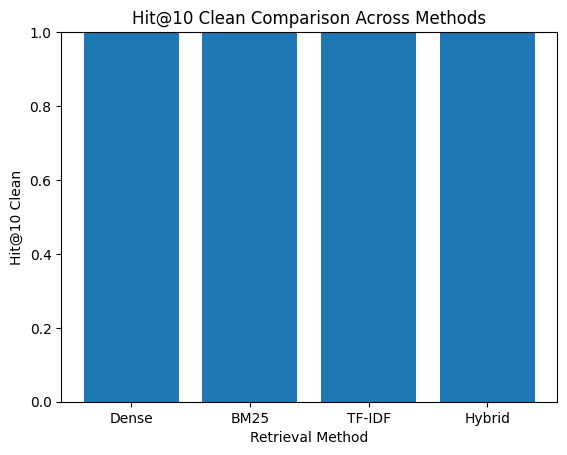

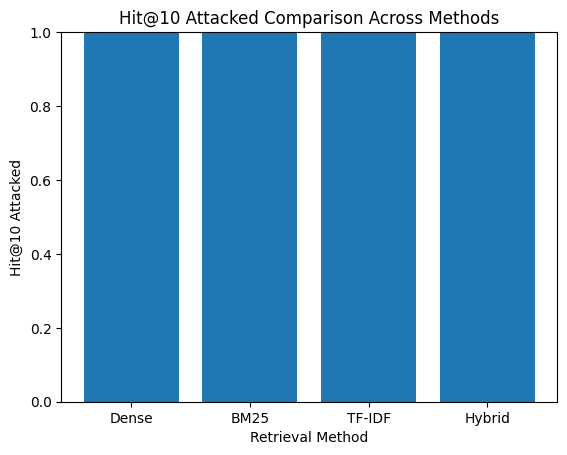

KeyError: 'MRR Clean'

In [18]:
# =========================================
# 17. METRIC VISUALIZATIONS
# =========================================

metric_names = ["Hit@10 Clean", "Hit@10 Attacked", "MRR Clean", "MRR Attacked"]
method_names_metrics = list(evaluation_summary.keys())

for metric in metric_names:
    values = [evaluation_summary[m][metric] for m in method_names_metrics]

    plt.figure()
    plt.bar(method_names_metrics, values)
    plt.ylim(0, 1)
    plt.xlabel("Retrieval Method")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison Across Methods")
    plt.show()

In [ ]:
# =========================================
# 18. METHOD COMPARISON USING BLOCKER COUNTS
# =========================================

methods = {
    "Dense": lambda q: retrieve_topk_precomputed(q, docs_attacked, doc_emb_attacked, k),
    "BM25": lambda q: retrieve_bm25(q, docs_attacked, bm25_attacked, k),
    "TF-IDF": lambda q: retrieve_tfidf(q, docs_attacked, tfidf_matrix_attacked, tfidf_attacked, k),
    "Hybrid": lambda q: retrieve_hybrid(q, docs_attacked, doc_emb_attacked, bm25_attacked, k, alpha=0.5),
}

print("===== METHOD COMPARISON =====")
for method_name, method_fn in methods.items():
    print(f"\n{method_name}")
    for q in queries:
        results = method_fn(q)
        blocker_hits = sum(1 for idx, _, _ in results if idx >= blocker_start_idx)
        print(f"  {q} -> {blocker_hits}/{k} blockers")

===== METHOD COMPARISON =====

Dense
  What is data science? -> 4/5 blockers
  How does evaluation work in machine learning? -> 5/5 blockers
  How are models optimized in artificial intelligence? -> 5/5 blockers
  What are machine learning systems used for? -> 5/5 blockers

BM25
  What is data science? -> 3/5 blockers
  How does evaluation work in machine learning? -> 5/5 blockers
  How are models optimized in artificial intelligence? -> 3/5 blockers
  What are machine learning systems used for? -> 4/5 blockers

TF-IDF
  What is data science? -> 4/5 blockers
  How does evaluation work in machine learning? -> 5/5 blockers
  How are models optimized in artificial intelligence? -> 3/5 blockers
  What are machine learning systems used for? -> 5/5 blockers

Hybrid
  What is data science? -> 4/5 blockers
  How does evaluation work in machine learning? -> 5/5 blockers
  How are models optimized in artificial intelligence? -> 4/5 blockers
  What are machine learning systems used for? -> 5/5 bl

Computed blocker counts automatically:
Dense -> [4, 5, 5, 5]
BM25 -> [3, 5, 3, 4]
TF-IDF -> [4, 5, 3, 5]
Hybrid -> [4, 5, 4, 5]


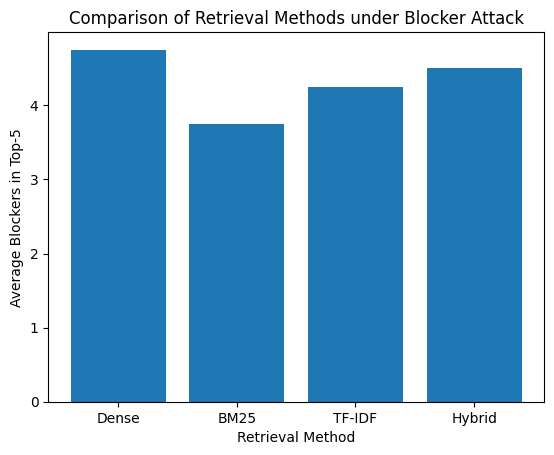

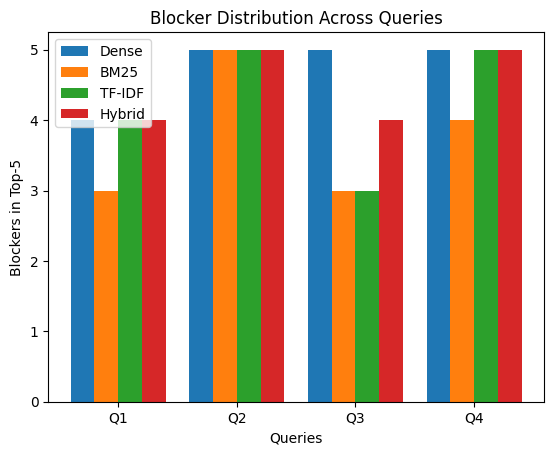

In [ ]:
# =========================================
# 19. AUTOMATIC BLOCKER COUNT PLOTS
# =========================================

method_results = {}

for method_name, method_fn in methods.items():
    blocker_list = []
    for q in queries:
        results = method_fn(q)
        blocker_hits = sum(1 for idx, _, _ in results if idx >= blocker_start_idx)
        blocker_list.append(blocker_hits)
    method_results[method_name] = blocker_list

print("Computed blocker counts automatically:")
for method_name, blocker_list in method_results.items():
    print(method_name, "->", blocker_list)

# Average blockers per method
method_names = list(method_results.keys())
avg_scores = [np.mean(method_results[m]) for m in method_names]

plt.figure()
plt.bar(method_names, avg_scores)
plt.xlabel("Retrieval Method")
plt.ylabel(f"Average Blockers in Top-{k}")
plt.title("Comparison of Retrieval Methods under Blocker Attack")
plt.show()

# Blockers per query for each method
queries_labels = [f"Q{i+1}" for i in range(len(queries))]
x = np.arange(len(queries_labels))
width = 0.2

plt.figure()
for i, method_name in enumerate(method_names):
    plt.bar(x + (i - 1.5) * width, method_results[method_name], width, label=method_name)

plt.xticks(x, queries_labels)
plt.xlabel("Queries")
plt.ylabel(f"Blockers in Top-{k}")
plt.title("Blocker Distribution Across Queries")
plt.legend()
plt.show()

In [ ]:
# =========================================
# 20. FINAL SUMMARY
# =========================================

print("\n===== FINAL SUMMARY =====")
print("This notebook evaluates retrieval robustness under blocker-document attack.")
print("We compared Dense, BM25, TF-IDF, and Hybrid retrieval.")
print("We measured:")
print("1. Number of blockers appearing in top-k results")
print("2. Rank changes of gold relevant documents before and after attack")
print("3. Hit@10 and MRR@10 before and after attack")
print("These results show how retrieval methods behave when the corpus is polluted with semantically similar blocker documents.")


===== FINAL SUMMARY =====
This notebook evaluates retrieval robustness under blocker-document attack.
We compared Dense, BM25, TF-IDF, and Hybrid retrieval.
We measured:
1. Number of blockers appearing in top-k results
2. Rank changes of gold relevant documents before and after attack
3. Hit@10 and MRR@10 before and after attack
These results show how retrieval methods behave when the corpus is polluted with semantically similar blocker documents.
